### Instalation Of Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

### Read CSV File

In [34]:
df = pd.read_csv("telecommunications_churn.csv")
df

,account_length,voice_mail_plan,voice_mail_messages,day_mins,evening_mins,night_mins,international_mins,customer_service_calls,international_plan,day_calls,day_charge,evening_calls,evening_charge,night_calls,night_charge,international_calls,international_charge,total_charge,churn
0,128,1,25,265.1,197.4,244.7,10.0,1,0,110,45.07,99,16.78,91,11.01,3,2.70,75.56,0
1,107,1,26,161.6,195.5,254.4,13.7,1,0,123,27.47,103,16.62,103,11.45,3,3.70,59.24,0
2,137,0,0,243.4,121.2,162.6,12.2,0,0,114,41.38,110,10.30,104,7.32,5,3.29,62.29,0
3,84,0,0,299.4,61.9,196.9,6.6,2,1,71,50.90,88,5.26,89,8.86,7,1.78,66.80,0
4,75,0,0,166.7,148.3,186.9,10.1,3,1,113,28.34,122,12.61,121,8.41,3,2.73,52.09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,1,36,156.2,215.5,279.1,9.9,2,0,77,26.55,126,18.32,83,12.56,6,2.67,60.10,0
3329,68,0,0,231.1,153.4,191.3,9.6,3,0,57,39.29,55,13.04,123,8.61,4,2.59,63.53,0
3330,28,0,0,180.8,288.8,191.9,14.1,2,0,109,30.74,58,24.55,91,8.64,6,3.81,67.74,0
3331,184,0,0,213.8,159.6,139.2,5.0,2,1,105,36.35,84,13.57,137,6.26,10,1.35,57.53,0


### Data Overview and Initial Exploration

In [35]:
print("The size of data:", df.size)
print("The number of rows and columns:", df.shape)
print("The Data type:", df.dtypes)

The size of data: 63327
The number of rows and columns: (3333, 19)
The Data type: account_length              int64
voice_mail_plan             int64
voice_mail_messages         int64
day_mins                  float64
evening_mins              float64
night_mins                float64
international_mins        float64
customer_service_calls      int64
international_plan          int64
day_calls                   int64
day_charge                float64
evening_calls               int64
evening_charge            float64
night_calls                 int64
night_charge              float64
international_calls         int64
international_charge      float64
total_charge              float64
churn                       int64
dtype: object


In [36]:
df.isnull().sum()

account_length            0
voice_mail_plan           0
voice_mail_messages       0
day_mins                  0
evening_mins              0
night_mins                0
international_mins        0
customer_service_calls    0
international_plan        0
day_calls                 0
day_charge                0
evening_calls             0
evening_charge            0
night_calls               0
night_charge              0
international_calls       0
international_charge      0
total_charge              0
churn                     0
dtype: int64

### Count of churn vs non-churn

In [37]:
chrun_counts = df['churn'].value_counts()
print(chrun_counts)

churn
0    2850
1     483
Name: count, dtype: int64


### Percentage distribution

In [38]:
churn_percentage = df['churn'].value_counts(normalize=True) * 100
print(churn_percentage)

churn
0    85.508551
1    14.491449
Name: proportion, dtype: float64


In [39]:
summary=df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
account_length,3333.0,101.064806,39.822106,1.00,74.00,101.00,127.00,243.00
voice_mail_plan,3333.0,0.276628,0.447398,0.00,0.00,0.00,1.00,1.00
voice_mail_messages,3333.0,8.099010,13.688365,0.00,0.00,0.00,20.00,51.00
day_mins,3333.0,179.775098,54.467389,0.00,143.70,179.40,216.40,350.80
evening_mins,3333.0,200.980348,50.713844,0.00,166.60,201.40,235.30,363.70
night_mins,3333.0,200.872037,50.573847,23.20,167.00,201.20,235.30,395.00
international_mins,3333.0,10.237294,2.791840,0.00,8.50,10.30,12.10,20.00
customer_service_calls,3333.0,1.562856,1.315491,0.00,1.00,1.00,2.00,9.00
international_plan,3333.0,0.096910,0.295879,0.00,0.00,0.00,0.00,1.00
day_calls,3333.0,100.435644,20.069084,0.00,87.00,101.00,114.00,165.00


### Separating Features and Target Variable

In [40]:
X = df.drop('churn', axis=1)
y = df['churn']

In [41]:
X['voice_mail_plan'] = X['voice_mail_plan'].astype('category')
X['international_plan'] = X['international_plan'].astype('category')

### Churn VS Non-Churn bar chart

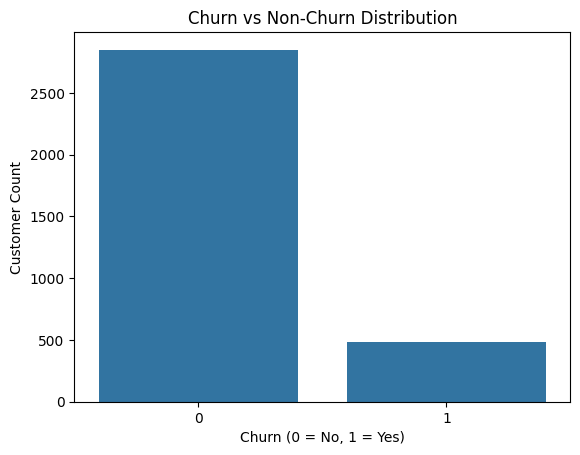

In [42]:

sns.countplot(x='churn', data=df)
plt.title("Churn vs Non-Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()

### Customer Service Calls vs Churn Box Plot


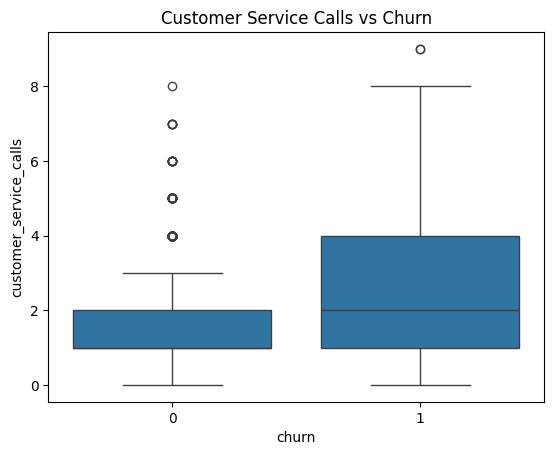

In [43]:

sns.boxplot(x='churn', y='customer_service_calls', data=df)
plt.title("Customer Service Calls vs Churn")
plt.show()

### International Plan vs Churn countplot


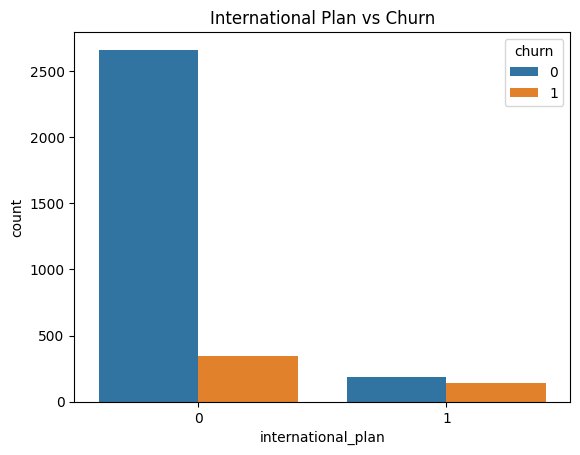

In [44]:

sns.countplot(x='international_plan', hue='churn', data=df)
plt.title("International Plan vs Churn")
plt.show()

### Total Charges vs Churn Box Plot

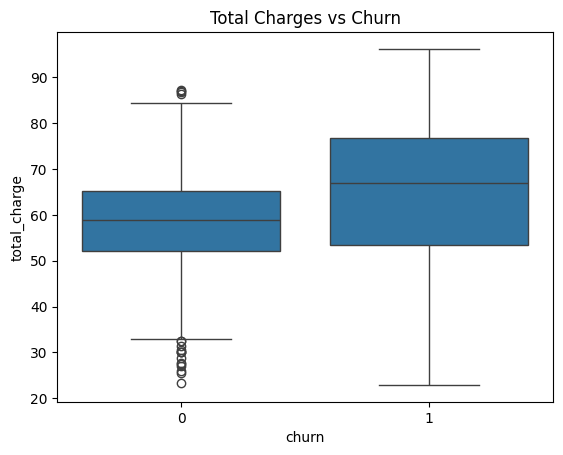

In [45]:

sns.boxplot(x='churn', y='total_charge', data=df)
plt.title("Total Charges vs Churn")
plt.show()

### Account Length vs Churn


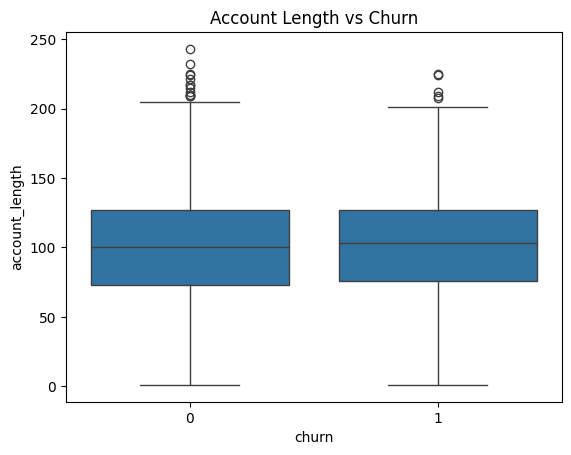

In [46]:

sns.boxplot(x='churn', y='account_length', data=df)
plt.title("Account Length vs Churn")
plt.show()

### Correlation Heatmap

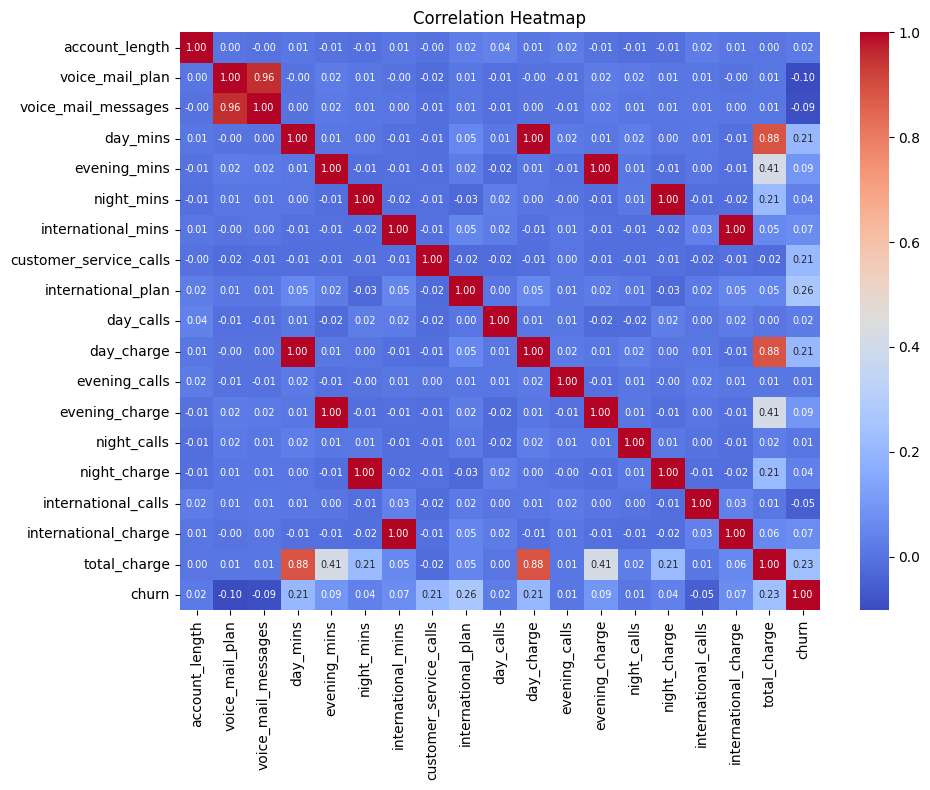

In [47]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}
)


plt.title("Correlation Heatmap", fontsize=12)
plt.tight_layout()
plt.show()


### Churn Rate by Customer Service Calls bar chart

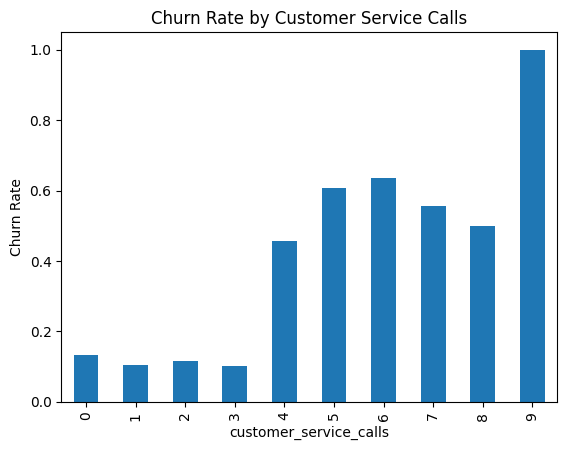

In [48]:

churn_rate = df.groupby('customer_service_calls')['churn'].mean()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Customer Service Calls")
plt.ylabel("Churn Rate")
plt.show()

### Churn Rate by International Plans

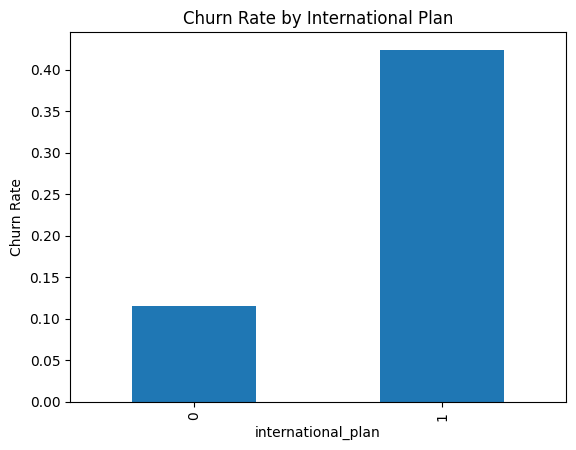

In [49]:
df.groupby('international_plan')['churn'].mean().plot(kind='bar')
plt.title("Churn Rate by International Plan")
plt.ylabel("Churn Rate")
plt.show()

### Distribution of Total Charges

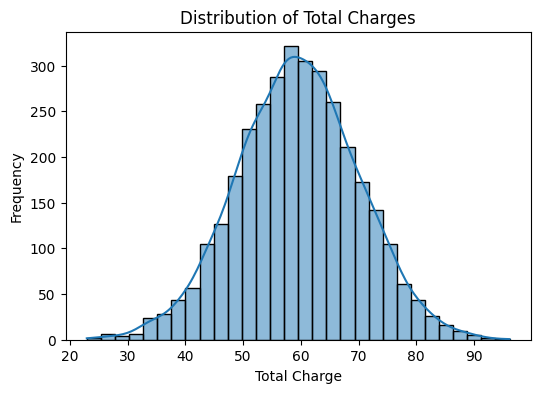

In [50]:
plt.figure(figsize=(6,4))
sns.histplot(df['total_charge'], bins=30, kde=True)
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charge")
plt.ylabel("Frequency")
plt.show()


### Day Minutes vs Total Charge Scatter Plot

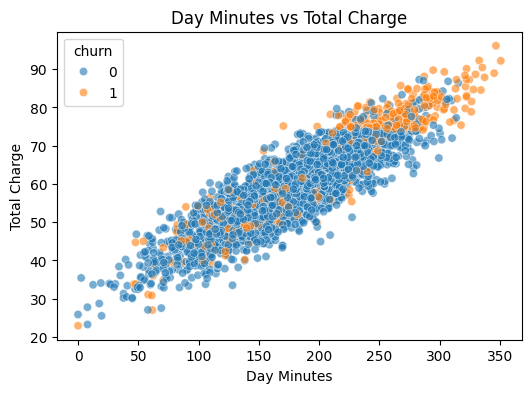

In [51]:
plt.figure(figsize=(6,4))
sns.scatterplot( x='day_mins', y='total_charge',hue='churn', data = df, alpha=0.6)
plt.title('Day Minutes vs Total Charge')
plt.xlabel("Day Minutes")
plt.ylabel("Total Charge")
plt.show()   

### International Minutes vs International Charge


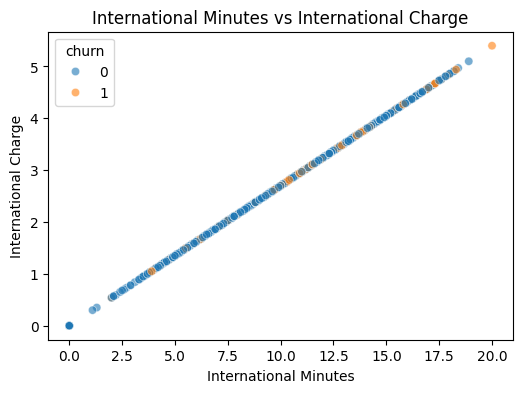

In [52]:

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='international_mins',
    y='international_charge',
    hue='churn',
    data=df,
    alpha=0.6
)
plt.title("International Minutes vs International Charge")
plt.xlabel("International Minutes")
plt.ylabel("International Charge")
plt.show()

### Model Building

In [53]:
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important because data is imbalanced
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2666, 18)
Test shape: (667, 18)


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 1.LogisticRegression

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.8590704647676162
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       570
           1       0.53      0.25      0.34        97

    accuracy                           0.86       667
   macro avg       0.71      0.61      0.63       667
weighted avg       0.83      0.86      0.84       667



### 2.KNeighbors Classifier

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.8935532233883059
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       570
           1       0.78      0.37      0.50        97

    accuracy                           0.89       667
   macro avg       0.84      0.68      0.72       667
weighted avg       0.88      0.89      0.88       667



### Random Forest Classifier

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)   # RF does not require scaling

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.967016491754123
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       570
           1       0.99      0.78      0.87        97

    accuracy                           0.97       667
   macro avg       0.98      0.89      0.93       667
weighted avg       0.97      0.97      0.97       667



### Support Vector Machine

In [58]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.9145427286356822
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       570
           1       0.83      0.52      0.64        97

    accuracy                           0.91       667
   macro avg       0.88      0.75      0.79       667
weighted avg       0.91      0.91      0.91       667



### Gradient Boosting Classifier

In [59]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.9685157421289355
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       570
           1       0.99      0.79      0.88        97

    accuracy                           0.97       667
   macro avg       0.98      0.90      0.93       667
weighted avg       0.97      0.97      0.97       667



In [60]:
model_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb)
}

model_results


{'Logistic Regression': 0.8590704647676162,
 'KNN': 0.8935532233883059,
 'Random Forest': 0.967016491754123,
 'SVM': 0.9145427286356822,
 'Gradient Boosting': 0.9685157421289355}

In [65]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    
    # Use scaled data where required
    if name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.968516,0.987179,0.793814,0.880000,0.911358
1,Random Forest,0.967016,0.987013,0.783505,0.873563,0.895216
3,SVM,0.914543,0.833333,0.515464,0.636943,0.891662
4,KNN,0.893553,0.782609,0.371134,0.503497,0.863492
0,Logistic Regression,0.859070,0.533333,0.247423,0.338028,0.817056


### Best Model Selection based on F1 Score

In [64]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]

print("Best Model Based on F1 Score:", best_model_name)


Best Model Based on F1 Score: Gradient Boosting
